In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler


# 1. Cargar el dataset
df = pd.read_csv('insurance.csv')

1.1 Variable categóricas: 
    de la documentation: sex (female, male), smoker (yes, no), region ( northeast, southeast, southwest, northwest)

    Strategie to encode:    smoking, sex -> binary (->encoding ordinal)
                            region: one-hot encoding (frequency to similar, no different levels for ordinal, Target encoding not because of low correlation to charges) 

In [114]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df = pd.get_dummies(df, columns=['region'], dtype=int)



1.2 Valores faltantes:

In [115]:
# find duplicates
duplicate_count = df.duplicated().sum()
print(f"Number duplicates: {duplicate_count}")

# delete duplicates
df = df.drop_duplicates()

region_cols = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

#find wrong values
valid_mask = (
    (df['age'] > 0) &
    (df['bmi'] > 0) &
    (df['children'] >= 0) &
    (df['charges'] > 0) &
    (df['sex'].isin([0, 1])) &
    (df['smoker'].isin([0, 1])) &
    (df[region_cols].sum(axis=1) == 1) &
    (df[region_cols].isin([0, 1]).all(axis=1))
)

invalid_rows = df[~valid_mask]

if not invalid_rows.empty:
    print("Invalid rows found:")
    print(invalid_rows)
else:
    print("No invalid rows found.")

df = df[valid_mask].copy()

Number duplicates: 1
No invalid rows found.


1.3 Outliers: 

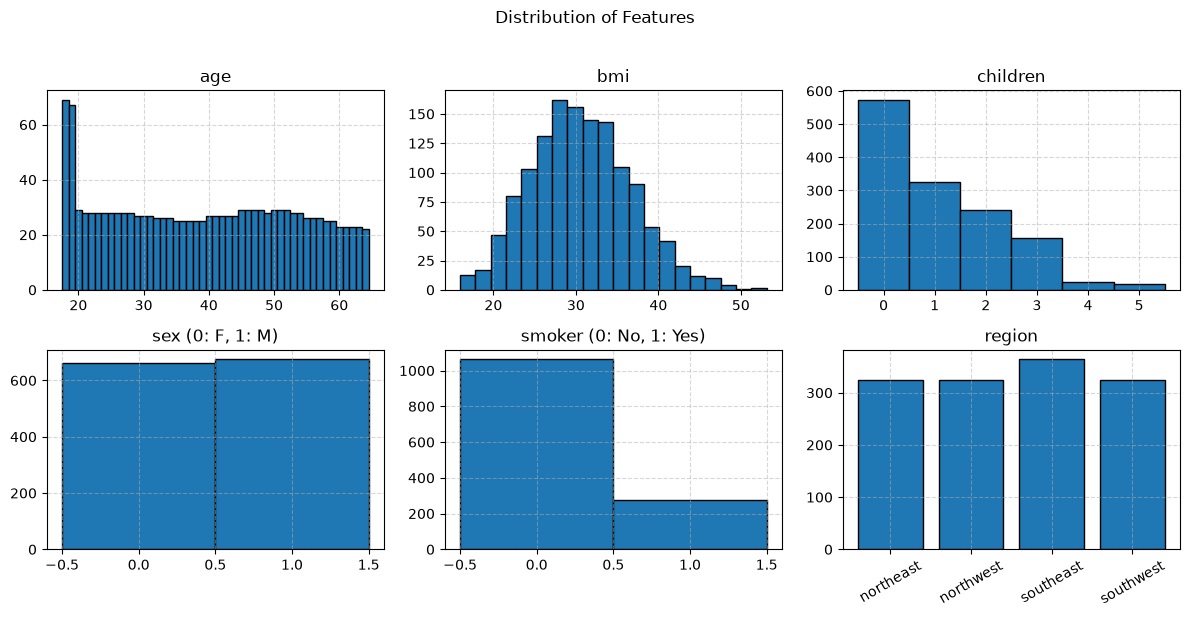

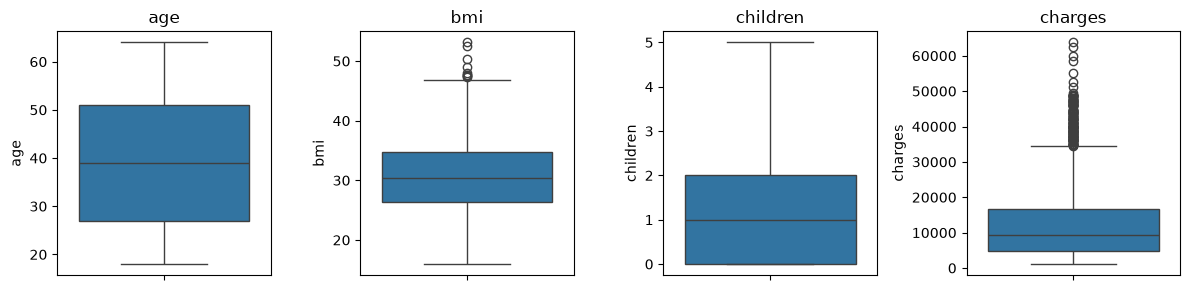

--- IQR Outlier Counts ---
age: 0
bmi: 9
children: 0
charges: 139

Z-score outliers (|z| > 3):
[ 0  4 18  7]


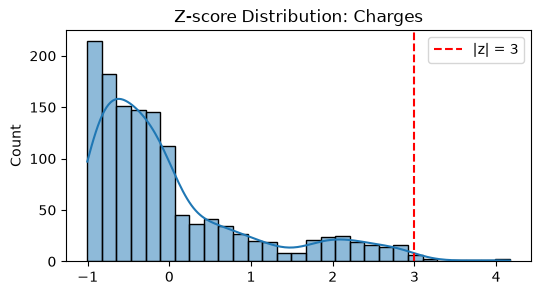

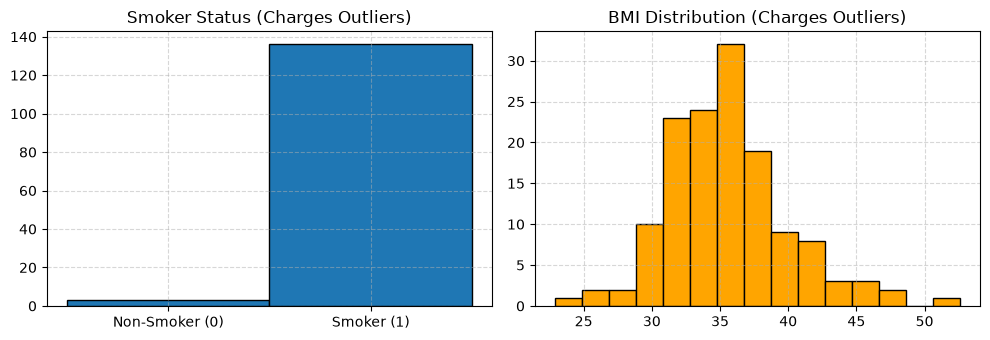

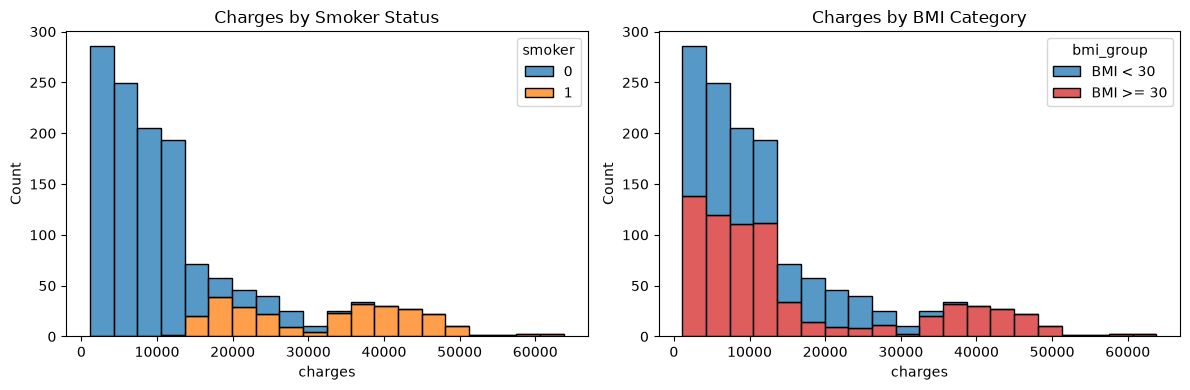

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

num_cols = ['age', 'bmi', 'children', 'charges']
region_cols = [
    'region_northeast',
    'region_northwest',
    'region_southeast',
    'region_southwest',
]

# 1. Feature Distributions
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes[0, 0].hist(
    df['age'],
    bins=np.arange(df['age'].min(), df['age'].max() + 2) - 0.5,
    edgecolor='black',
)
axes[0, 0].set_title('age')

axes[0, 1].hist(df['bmi'], bins=20, edgecolor='black')
axes[0, 1].set_title('bmi')

axes[0, 2].hist(
    df['children'],
    bins=np.arange(df['children'].min(), df['children'].max() + 2) - 0.5,
    edgecolor='black',
)
axes[0, 2].set_title('children')

axes[1, 0].hist(df['sex'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
axes[1, 0].set_title('sex (0: F, 1: M)')

axes[1, 1].hist(df['smoker'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
axes[1, 1].set_title('smoker (0: No, 1: Yes)')

axes[1, 2].bar(
    [c.replace('region_', '') for c in region_cols],
    df[region_cols].sum(),
    edgecolor='black',
)
axes[1, 2].set_title('region')
axes[1, 2].tick_params(axis='x', rotation=30)

for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Distribution of Features', y=1.02)
plt.tight_layout()
plt.show()

# 2. Boxplots for Numerical Features
plt.figure(figsize=(12, 3))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# 3. IQR & Z-score Outlier Analysis
print("--- IQR Outlier Counts ---")
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers)}")

z_scores = np.abs(stats.zscore(df[num_cols]))
print(f"\nZ-score outliers (|z| > 3):\n{(z_scores > 3).sum(axis=0)}")

plt.figure(figsize=(6, 3))
sns.histplot(stats.zscore(df['charges']), kde=True)
plt.axvline(3, color='r', linestyle='--', label='|z| = 3')
plt.title('Z-score Distribution: Charges')
plt.legend()
plt.show()

# 4. Charges Outlier Breakdown (Smoker & BMI)
q1, q3 = df['charges'].quantile(0.25), df['charges'].quantile(0.75)
iqr = q3 - q1
charges_outliers = df[
    (df['charges'] < q1 - 1.5 * iqr) | (df['charges'] > q3 + 1.5 * iqr)
]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(
    charges_outliers['smoker'], bins=[-0.5, 0.5, 1.5], edgecolor='black'
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Smoker (0)', 'Smoker (1)'])
axes[0].set_title('Smoker Status (Charges Outliers)')

axes[1].hist(charges_outliers['bmi'], bins=15, edgecolor='black', color='orange')
axes[1].set_title('BMI Distribution (Charges Outliers)')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Charges Distributions by Smoker & BMI Category
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    data=df,
    x='charges',
    hue='smoker',
    multiple='stack',
    bins=20,
    palette=['#1f77b4', '#ff7f0e'],
    edgecolor='black',
    ax=axes[0],
)
axes[0].set_title('Charges by Smoker Status')

sns.histplot(
    data=df.assign(
        bmi_group=(df['bmi'] >= 30).map(
            {True: 'BMI >= 30', False: 'BMI < 30'}
        )
    ),
    x='charges',
    hue='bmi_group',
    multiple='stack',
    bins=20,
    palette=['#1f77b4', '#d62728'],
    edgecolor='black',
    ax=axes[1],
)
axes[1].set_title('Charges by BMI Category')

plt.tight_layout()
plt.show()

We choose to keep all datapoints, the outliers can be explained by their smoker status and the bmi.
The high bmi datapoints are to be expected in the real world as well
5 children are possible

1.4 Characterísticas
    [pearson correlation matrix, mutual information matrix]
    result: variables uncorrelated, keep all [or we could do the RFE (wrappers)]

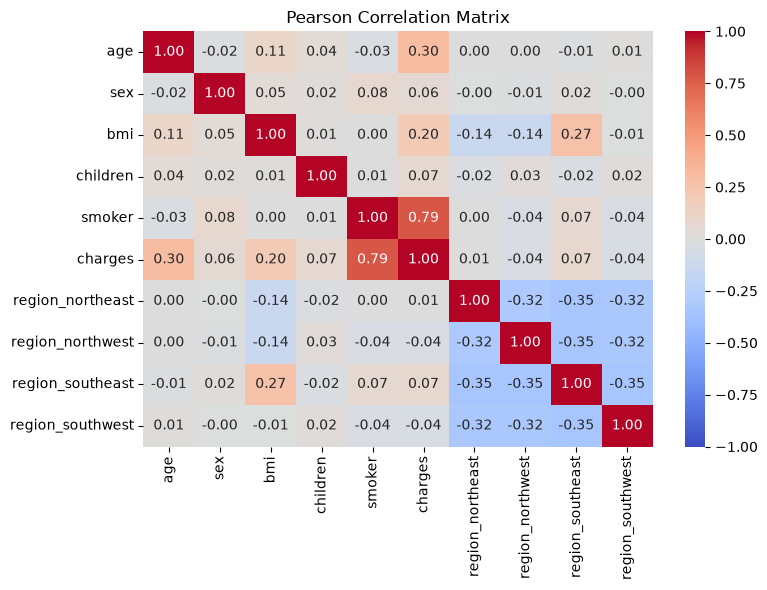

In [117]:
# Pearson Correlation Matrix
corr_matrix = df.corr(method='pearson')

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    cbar=True
)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

We will ommit the regions as they show a very low linear correlation with 'charges' (max. 0.07 inn southeast which is in turn correlated to bmi)
No other category is ommited, although the correlation of charge with children is similary low, the amount of data is sufficiently large for the number of categorys and the saving in amount of categorys is lower than the 4 dummy variables.
No strong cross correlation is detected between other data points

In [118]:
region_cols = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
df = df.drop(columns=region_cols)
df.to_csv('insurance_cleaned.csv', index=False)

for scaling we use z-score, which is already included in the training library